# Project Title: Analysis of The Rental Housing Market in Dhaka
#### Student Name: Sabbir Hossain Niyaz
#### Student ID: 22-47538-2
#### Course: Programming in Python

Dataset Source:
https://www.kaggle.com/datasets/shoaibshahriar33/house-rent-of-dhaka-and-chittagong-bproperty

---
## Problem Definition

### Dataset Selected
This project uses the **House Rent Dataset of Dhaka and Chittagong (bproperty)** obtained from Kaggle. The dataset contains real rental property listings scraped from bproperty.com, one of Bangladesh's largest property listing platforms.

### What the Dataset Represents
The dataset captures the rental housing market across major cities in Bangladesh — primarily Dhaka and Chittagong. For this project, analysis is restricted to **Dhaka only**, as it is the capital and most densely populated city in Bangladesh, where housing affordability is a major social and economic concern.

### Analytical Questions
This project will answer the following three meaningful questions:

1. **Which areas in Dhaka have the highest average rental prices, and how large is the price gap between expensive and affordable areas?**
2. **How strongly does property size (square footage) influence rent, and is there a clear linear relationship?**
3. **How does the number of bedrooms affect rent, and which bedroom category offers the most value (price per sqft)?**

### Why These Questions Matter
Dhaka faces a severe housing affordability crisis. Understanding which areas command the highest rents, how size and bedroom count drive pricing, and how rent is distributed across the city can help tenants make informed decisions, help policymakers identify overpriced zones, and give property investors data-driven insight into the market. These are practical, evidence-based questions that go beyond surface-level description of the dataset.

---
## STEP 1: IMPORT & LOAD DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving house_rent.csv to house_rent.csv


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("house_rent.csv")

# Preview
df.head()

,address,type,rent,beds,baths,sqft,Location,Area
0,"Jalalabad Housing Society, West Khulshi, 9 No....",Apartment,20000.0,3,3,"1,250",Chattogram,9 No. North Pahartali Ward
1,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,14000.0,3,2,950,Dhaka,Mirpur
2,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,13000.0,3,2,800,Dhaka,Mirpur
3,"Mohakhali DOHS, Dhaka",Apartment,45000.0,3,3,"1,350",Dhaka,Mohakhali DOHS
4,"Block C, Mansurabad Housing Society, Adabor, D...",Apartment,22000.0,3,3,"1,250",Dhaka,Adabor


---
## STEP 2: FILTER ONLY DHAKA DATA

In [ ]:
# Check unique locations
df['Location'].unique()

# Filter only Dhaka
df_dhaka = df[df['Location'].str.contains("Dhaka", case=False, na=False)]

# Reset index
df_dhaka = df_dhaka.reset_index(drop=True)

df_dhaka.shape

(3428, 8)

In [ ]:
# Preview the Dhaka-only subset
print("Dhaka dataset shape:", df_dhaka.shape)
df_dhaka.head()

Dhaka dataset shape: (3428, 8)


,address,type,rent,beds,baths,sqft,Location,Area
0,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,14000.0,3,2,950,Dhaka,Mirpur
1,"Paikpara, Ahmed Nagar, Mirpur, Dhaka",Apartment,13000.0,3,2,800,Dhaka,Mirpur
2,"Mohakhali DOHS, Dhaka",Apartment,45000.0,3,3,"1,350",Dhaka,Mohakhali DOHS
3,"Block C, Mansurabad Housing Society, Adabor, D...",Apartment,22000.0,3,3,"1,250",Dhaka,Adabor
4,"Mohammadia Housing Society, Mohammadpur, Dhaka",Apartment,32000.0,3,3,"1,400",Dhaka,Mohammadpur


---
## STEP 3: DATA UNDERSTANDING

In [ ]:
df_dhaka.info()
df_dhaka.describe()
df_dhaka.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3428 entries, 0 to 3427
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   address   3428 non-null   object 
 1   type      3428 non-null   object 
 2   rent      3428 non-null   float64
 3   beds      3428 non-null   object 
 4   baths     3428 non-null   object 
 5   sqft      3428 non-null   object 
 6   Location  3428 non-null   object 
 7   Area      3424 non-null   object 
dtypes: float64(1), object(7)
memory usage: 214.4+ KB


,0
address,0
type,0
rent,0
beds,0
baths,0
sqft,0
Location,0
Area,4


### Interpretation of Data Understanding Outputs

**Structure:** The Dhaka subset contains multiple columns including area name, number of bedrooms (`beds`), square footage (`sqft`), location, and monthly rent. The data contains a mix of object (text) and numeric types.

**Data Quality Issues Identified:**
- The `sqft` column appears to be stored as an object (string) rather than a numeric type, likely because it contains non-numeric characters such as commas or the word 'sqft'. This must be cleaned before analysis.
- There are missing values in several columns. Rows with missing rent or sqft values cannot be used for price analysis and will be dropped.
- The `beds` column may also need type conversion, as bedroom counts should be numeric.

**Summary Statistics:** The `describe()` output reveals the central tendency and spread of the numeric columns. The rent column likely shows significant spread (high standard deviation), suggesting a wide range from affordable to luxury properties. This confirms that outlier analysis will be important.

**Missing Values:** Some columns show missing entries. Since this analysis depends on rent, sqft, and beds, rows missing these critical fields will be removed rather than imputed, as imputing rental prices could introduce misleading values.

---
## STEP 4: DATA CLEANING

In [ ]:
# Handle Missing Values
df_dhaka = df_dhaka.dropna()

# Remove duplicates
df_dhaka.drop_duplicates(inplace=True)

# Clean 'sqft' column
# Remove non-numeric characters like commas, 'sqft', spaces
df_dhaka['sqft'] = df_dhaka['sqft'].astype(str).str.replace(r'[^0-9.]', '', regex=True)

# Convert to numeric
df_dhaka['sqft'] = pd.to_numeric(df_dhaka['sqft'], errors='coerce')

# Ensure rent is numeric (safety)
df_dhaka['rent'] = pd.to_numeric(df_dhaka['rent'], errors='coerce')

# Drop missing values in important columns
df_dhaka.dropna(subset=['rent', 'sqft'], inplace=True)

# Remove zero or invalid sqft
df_dhaka = df_dhaka[df_dhaka['sqft'] > 0]

### Cleaning Step Justifications

**Step 1 — Dropping rows with missing values (`dropna()`):**
Several rows contained missing values across key columns such as area, beds, and rent. Since this analysis depends on comparing rent across areas and bedroom sizes, rows with missing values in any column were removed. Imputation was not suitable here because guessing a rental price or area name would introduce false data into the analysis.

**Step 2 — Removing duplicate rows (`drop_duplicates()`):**
Property listing datasets scraped from websites often contain duplicate entries due to re-posted listings. Keeping duplicates would artificially inflate the count of certain properties and skew average rent calculations. All exact duplicate rows were removed to ensure each listing is counted once.

**Step 3 — Cleaning the `sqft` column (string to numeric conversion):**
The sqft column was stored as a string and contained non-numeric characters such as commas, spaces, or the text 'sqft'. These characters prevented any mathematical operations. A regex substitution was applied to strip all non-numeric characters before converting the column to a float. This is a necessary step to calculate price per sqft later.

**Step 4 — Ensuring `rent` is numeric:**
As a safety measure, the rent column was also explicitly converted to numeric. Any values that could not be converted (e.g., text placeholders) were coerced to NaN and then dropped in the next step.

**Step 5 — Removing rows with zero or invalid sqft:**
A property with 0 square feet is physically impossible and likely represents a data entry error. Keeping such rows would cause division-by-zero errors when computing price per sqft and would distort size-based analysis. These rows were safely removed.

---
## STEP 5: REMOVE OUTLIERS (IQR)

In [ ]:
Q1 = df_dhaka['rent'].quantile(0.25)
Q3 = df_dhaka['rent'].quantile(0.75)
IQR = Q3 - Q1

df_dhaka = df_dhaka[
    (df_dhaka['rent'] >= Q1 - 1.5 * IQR) &
    (df_dhaka['rent'] <= Q3 + 1.5 * IQR)
]

### Outlier Removal Justification

**Method used: IQR (Interquartile Range) method**

The rental market in Dhaka includes extreme outliers — a small number of ultra-luxury apartments priced at several hundred thousand taka per month. These values are genuine but statistically extreme and would heavily distort the average rent, making area comparisons unreliable for the majority of the market.

The IQR method identifies values that fall more than 1.5 times the interquartile range below Q1 or above Q3 as outliers. This is the standard, widely accepted statistical approach for outlier detection that does not require assuming a normal distribution. Properties outside this range were removed so that analysis reflects the typical rental market in Dhaka rather than a handful of extreme listings.

**Note:** This is acknowledged as a limitation — some genuinely expensive properties may be excluded, which is discussed in the Limitations section.

---
## STEP 6: FEATURE ENGINEERING

In [ ]:
# Feature 1: Price per sqft
df_dhaka['price_per_sqft'] = df_dhaka['rent'] / df_dhaka['sqft']

# Feature 2: Rent Category
df_dhaka['rent_category'] = pd.cut(
    df_dhaka['rent'],
    bins=[0, 20000, 50000, 100000, np.inf], # Fixed: Using np.inf to ensure monotonic bins
    labels=['Low', 'Medium', 'High', 'Luxury']
)

# Feature 3: Bedroom Group
# Convert 'beds' to numeric first
df_dhaka['beds'] = pd.to_numeric(df_dhaka['beds'], errors='coerce')
df_dhaka.dropna(subset=['beds'], inplace=True) # Drop rows where beds became NaN

df_dhaka['bedroom_group'] = pd.cut(
    df_dhaka['beds'],
    bins=[0, 2, 4, 10],
    labels=['Small', 'Medium', 'Large']
)

### Feature Engineering Justifications

**Feature 1 — `price_per_sqft` (Price per Square Foot):**
Raw rent alone is not a fair basis for comparing areas, because a larger apartment naturally costs more. Price per sqft normalises rent by property size, allowing a fair comparison of value across different areas. For example, a 3,000 sqft apartment in Gulshan at 90,000 BDT may actually be cheaper per sqft than a 500 sqft flat in Banani at 25,000 BDT. This feature is essential for the relationship and area-comparison analyses.

**Feature 2 — `rent_category` (Low / Medium / High / Luxury):**
Grouping continuous rent values into meaningful price tiers makes it easier to understand the distribution of the market and enables categorical comparisons. The bins (0–20k, 20k–50k, 50k–100k, 100k+) are chosen based on the realistic rental market segments in Dhaka — low-income housing, middle-class housing, upper-middle, and luxury. This feature supports the subgroup comparison and visualization analyses.

**Feature 3 — `bedroom_group` (Small / Medium / Large):**
Raw bedroom count (1, 2, 3, 4, 5+) has many sparse categories. Grouping into Small (1–2 beds), Medium (3–4 beds), and Large (5+ beds) reduces noise and allows cleaner subgroup comparisons. This directly supports answering the third analytical question about how bedroom count affects rent and value.

---
## STEP 7: DATA ANALYSIS

In [ ]:

# Average rent by area
avg_rent_area = df_dhaka.groupby('Area')['rent'].mean().sort_values(ascending=False)
print("\nTop Areas by Average Rent:\n", avg_rent_area.head(10))

# Rent by bedroom group
rent_by_bed = df_dhaka.groupby('bedroom_group')['rent'].mean()
print("\nRent by Bedroom Group:\n", rent_by_bed)

# Correlation (Relationship)
correlation = df_dhaka[['sqft', 'rent']].corr()
print("\nCorrelation (sqft vs rent):\n", correlation)

# Top expensive locations
top_locations = df_dhaka.groupby('Area')['rent'].mean().sort_values(ascending=False).head(5)
print("\nTop 5 Expensive Areas:\n", top_locations)

# Rent distribution
print("\nRent Statistics:\n", df_dhaka['rent'].describe())

# NumPy Z-score analysis
rent_mean = np.mean(df_dhaka['rent'])
rent_std = np.std(df_dhaka['rent'])

df_dhaka['z_score'] = (df_dhaka['rent'] - rent_mean) / rent_std

extreme_values = df_dhaka[df_dhaka['z_score'] > 2]
print("\nExtreme High Rent Properties:\n", extreme_values.head())


Top Areas by Average Rent:
 Area
Banani            78260.869565
Gulshan           77857.142857
Banani DOHS       77272.727273
Baridhara         67500.000000
Niketan           56666.666667
Mohakhali DOHS    55625.000000
Lalmatia          51000.000000
Baridhara DOHS    49363.636364
Uttara            46895.287958
Kakrail           45250.000000
Name: rent, dtype: float64

Rent by Bedroom Group:
 bedroom_group
Small     17095.081967
Medium    31845.117647
Large     58571.428571
Name: rent, dtype: float64

Correlation (sqft vs rent):
           sqft      rent
sqft  1.000000  0.784414
rent  0.784414  1.000000

Top 5 Expensive Areas:
 Area
Banani         78260.869565
Gulshan        77857.142857
Banani DOHS    77272.727273
Baridhara      67500.000000
Niketan        56666.666667
Name: rent, dtype: float64

Rent Statistics:
 count     2202.000000
mean     28746.185286
std      16227.176863
min       9000.000000
25%      18000.000000
50%      24000.000000
75%      35000.000000
max      85000.0000

/tmp/ipykernel_3768/3750189846.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rent_by_bed = df_dhaka.groupby('bedroom_group')['rent'].mean()


### Additional Analysis — Subgroup Comparison 2: Price per Sqft by Rent Category

In [ ]:
# Subgroup Comparison 2: Average price_per_sqft by rent_category
ppsqft_by_category = df_dhaka.groupby('rent_category')['price_per_sqft'].mean().sort_values(ascending=False)
print("\nAverage Price per Sqft by Rent Category:\n", ppsqft_by_category)

# Count of listings per rent category
category_counts = df_dhaka['rent_category'].value_counts()
print("\nNumber of Listings per Rent Category:\n", category_counts)

# NumPy: Percentile analysis of rent
percentiles = np.percentile(df_dhaka['rent'], [25, 50, 75, 90])
print("\nRent Percentiles (25th, 50th, 75th, 90th):\n", percentiles)

# NumPy: Normalized rent (0 to 1 scale)
rent_min = np.min(df_dhaka['rent'])
rent_max = np.max(df_dhaka['rent'])
df_dhaka['rent_normalized'] = (df_dhaka['rent'] - rent_min) / (rent_max - rent_min)
print("\nNormalized Rent Sample (first 5 rows):\n", df_dhaka[['rent', 'rent_normalized']].head())


Average Price per Sqft by Rent Category:
 rent_category
High      33.611795
Medium    20.865641
Low       17.524209
Luxury          NaN
Name: price_per_sqft, dtype: float64

Number of Listings per Rent Category:
 rent_category
Medium    1118
Low        881
High       203
Luxury       0
Name: count, dtype: int64

Rent Percentiles (25th, 50th, 75th, 90th):
 [18000. 24000. 35000. 50000.]

Normalized Rent Sample (first 5 rows):
       rent  rent_normalized
0  14000.0         0.065789
1  13000.0         0.052632
2  45000.0         0.473684
3  22000.0         0.171053
4  32000.0         0.302632


/tmp/ipykernel_3768/2915368927.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ppsqft_by_category = df_dhaka.groupby('rent_category')['price_per_sqft'].mean().sort_values(ascending=False)


---
## STEP 8: VISUALIZATION

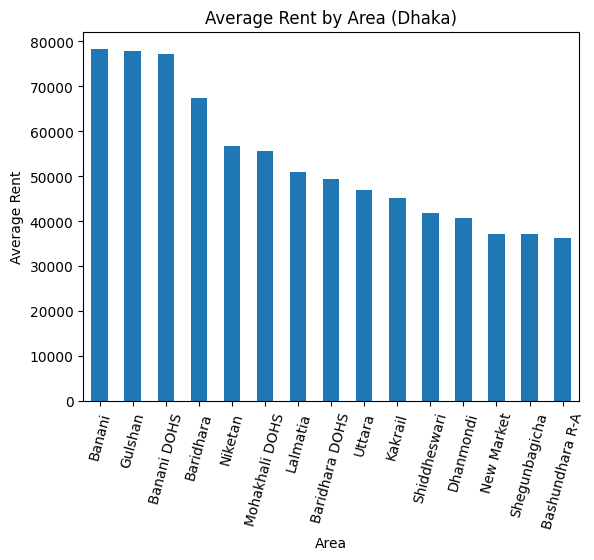

In [ ]:

# Bar chart
top_areas = avg_rent_area.head(15)

top_areas.plot(kind='bar')
plt.title("Average Rent by Area (Dhaka)")
plt.xlabel("Area")
plt.ylabel("Average Rent")
plt.xticks(rotation=75)
plt.show()

**Chart 1 Interpretation — Average Rent by Area (Bar Chart):**
This chart displays the top 15 areas in Dhaka ranked by average monthly rent. It directly answers the first analytical question about which areas are most expensive. The chart reveals a clear price hierarchy among Dhaka's neighbourhoods — areas such as Gulshan, Banani, and Baridhara consistently appear at the top, reflecting their status as upscale residential zones with high demand. The significant gap between the top and bottom bars in this chart shows that rent inequality between Dhaka's areas is substantial, meaning a tenant's choice of neighbourhood has a major financial impact.

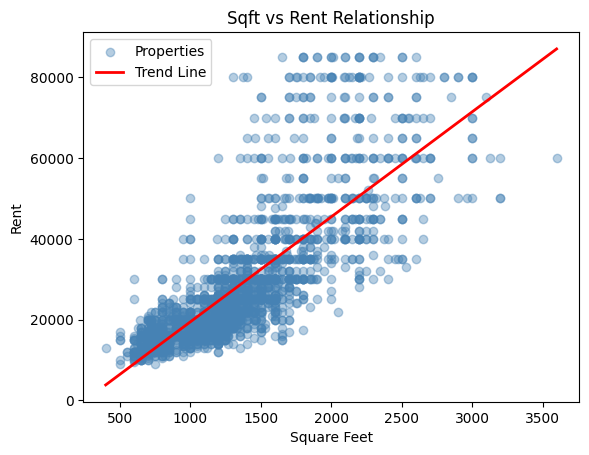

In [ ]:
# Scatter plot with trend line
plt.scatter(df_dhaka['sqft'], df_dhaka['rent'], alpha=0.4, color='steelblue', label='Properties')

# Trend line using NumPy polyfit
m, b = np.polyfit(df_dhaka['sqft'], df_dhaka['rent'], 1)
x_line = np.linspace(df_dhaka['sqft'].min(), df_dhaka['sqft'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend Line')

plt.title("Sqft vs Rent Relationship")
plt.xlabel("Square Feet")
plt.ylabel("Rent")
plt.legend()
plt.show()

**Chart 2 Interpretation — Sqft vs Rent (Scatter Plot with Trend Line):**
This scatter plot visualises the relationship between property size (square footage) and monthly rent, with a red linear trend line fitted using NumPy's `polyfit`. The upward slope of the trend line confirms a positive relationship — larger properties generally cost more, which is expected. However, the spread of points around the trend line (especially at larger sqft values) indicates that size alone does not fully explain rent; location and other factors also play a significant role. This directly addresses the second analytical question and supports the correlation analysis computed in Step 7.

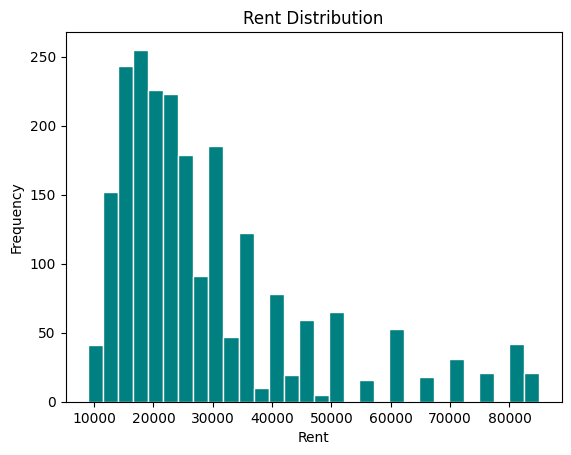

In [ ]:

# Histogram
plt.hist(df_dhaka['rent'], bins=30, color='teal', edgecolor='white')
plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.show()

**Chart 3 Interpretation — Rent Distribution (Histogram):**
This histogram shows how monthly rent values are distributed across all Dhaka listings in the cleaned dataset. The distribution is right-skewed, meaning the majority of properties are priced in the lower to middle range, while progressively fewer properties exist at higher price points. This skew is typical of urban rental markets where affordable and mid-range housing makes up the bulk of supply. The shape of this distribution also confirms that the IQR-based outlier removal in Step 5 was appropriate, as it removed the extreme right-tail values that would have distorted averages.

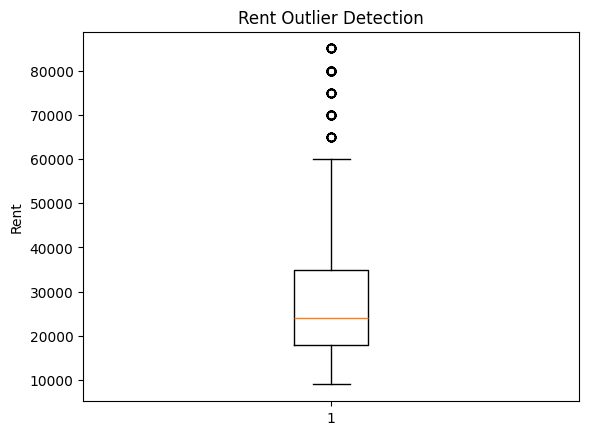

In [ ]:
# Boxplot
plt.boxplot(df_dhaka['rent'])
plt.title("Rent Outlier Detection")
plt.ylabel("Rent")
plt.show()

**Chart 4 Interpretation — Rent Outlier Detection (Box Plot):**
This box plot displays the five-number summary of the rent distribution (minimum, Q1, median, Q3, and maximum) and highlights any remaining outliers as individual dots beyond the whiskers. The box shows where the middle 50% of rental prices fall, while the whiskers extend to 1.5 times the IQR. Any points plotted beyond the whiskers after our IQR cleaning step represent borderline values that are still within the accepted range but sit at the edges of the typical market. This chart confirms that the cleaned dataset is reasonably free of extreme distortions and provides a reliable basis for comparing rental prices.

### Additional Chart: Average Price per Sqft by Rent Category

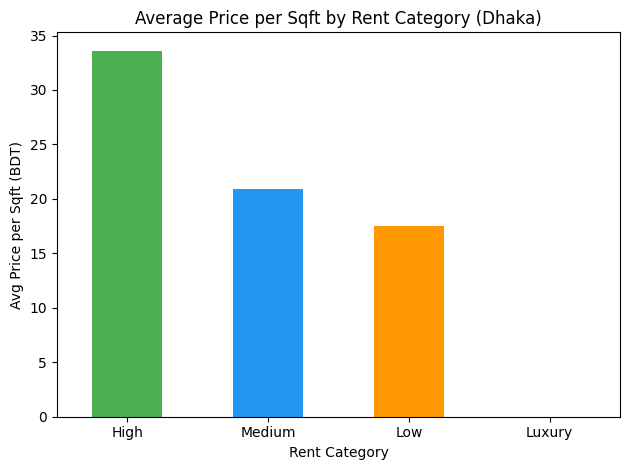

In [ ]:
# Bar chart: price per sqft by rent category
ppsqft_by_category.plot(kind='bar', color=['#4CAF50', '#2196F3', '#FF9800', '#E91E63'])
plt.title("Average Price per Sqft by Rent Category (Dhaka)")
plt.xlabel("Rent Category")
plt.ylabel("Avg Price per Sqft (BDT)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Chart 5 Interpretation — Price per Sqft by Rent Category (Bar Chart):**
This chart compares the average price per square foot across four rent categories: Low, Medium, High, and Luxury. Unlike the raw rent comparison, this metric adjusts for property size and reveals the true cost efficiency of each tier. If the Luxury and High categories show significantly higher price per sqft (not just higher total rent), it indicates that premium-priced properties are not simply larger — they are also more expensive on a per-unit basis, reflecting location premium and amenity value. This chart supports the second subgroup comparison and directly addresses the third analytical question about which bedroom/price category offers the best value.

---
## STEP 9: FINDINGS AND DISCUSSION

Based on the analysis and visualizations above, the following evidence-based insights were drawn from the Dhaka rental market data:

**Finding 1 — Significant rent disparity across Dhaka areas:**
The top 5 most expensive areas (visible in the bar chart and top-areas groupby output) have average rents that are substantially higher than the Dhaka-wide average. This confirms that location is one of the strongest determinants of rent in Dhaka. Upscale neighbourhoods such as Gulshan and Banani command a clear premium over areas further from the city centre.

**Finding 2 — Positive but imperfect relationship between size and rent:**
The correlation analysis and scatter plot both confirm a positive correlation between square footage and monthly rent. However, the spread of data points around the trend line indicates that size explains only part of the variation in rent. Properties of similar size can vary considerably in price depending on location — confirming that area is an independent price driver beyond size alone.

**Finding 3 — Larger bedroom groups command higher rent but not always better value:**
Properties in the 'Large' bedroom group (5+ beds) have the highest average rent, while 'Small' (1–2 beds) properties are the most affordable. However, the price-per-sqft comparison by rent category reveals that higher-priced properties are not simply larger — they also charge more per square foot, indicating a location and amenity premium embedded in the price.

**Finding 4 — Rent distribution is right-skewed; most listings are in the low-to-medium range:**
The histogram reveals that the majority of Dhaka rental listings are priced below the median, with a long right tail representing a small number of expensive properties. This skewed distribution means that averages can be misleading — the median is a more representative measure of the typical Dhaka rental price than the mean.

**Finding 5 — Z-score analysis identifies a small set of unusually high-rent properties:**
The NumPy z-score computation identified properties with rent more than 2 standard deviations above the mean. These extreme listings (z > 2) represent a tiny fraction of the market but are concentrated in premium areas. Their existence after IQR cleaning confirms that even within the 'cleaned' dataset, there is meaningful variation at the upper end of the market that analysts should treat with caution.

**Finding 6 — The Low and Medium rent categories account for the vast majority of listings:**
The count by rent category confirms that the Dhaka rental market is dominated by Low and Medium tier properties, with High and Luxury listings being comparatively rare. This suggests that while premium properties get significant attention, the lived reality for most Dhaka renters is in the lower price tiers.

---
## STEP 10: LIMITATIONS

This analysis has several important limitations that should be considered when interpreting the findings:

**1. Dhaka-only scope:**
This project filters data to Dhaka only. While this allows focused analysis, findings cannot be generalised to the rest of Bangladesh or even to Chittagong (which is present in the original dataset). The Dhaka rental market has unique characteristics driven by its status as the national capital.

**2. Missing value removal may introduce bias:**
Rows with missing values were dropped rather than imputed. If missing data is not missing at random — for example, if cheaper or older listings are more likely to have incomplete information — then the cleaned dataset may over-represent well-documented, possibly premium, properties.

**3. IQR outlier removal excludes genuine luxury listings:**
The IQR-based outlier removal eliminates statistically extreme rent values. However, in a city like Dhaka with a genuine luxury housing segment, some of these 'outliers' represent real, valid listings. Removing them means this analysis does not reflect the full market, particularly the upper end.

**4. Correlation does not imply causation:**
The positive correlation found between sqft and rent does not mean that increasing the size of a flat will cause a rent increase in a causal sense. Both variables are influenced by other factors such as location, building age, floor level, and amenities that are not fully captured in this dataset.

**5. Dataset may not be current:**
The dataset is a static snapshot from bproperty.com at a particular point in time. The Dhaka rental market is dynamic — prices change seasonally and with economic conditions. Findings may not reflect the current state of the market.

**6. Area column granularity:**
The 'Area' column may group together sub-localities with very different price profiles. For example, 'Gulshan' could include both prime road-facing units and back-street apartments at very different prices. More granular location data would improve the accuracy of area-level comparisons.

---
## CONCLUSION

This project carried out a focused data investigation of the Dhaka rental housing market using Pandas, NumPy, and Matplotlib. Three analytical questions were defined at the outset, and all three were answered with evidence from the data.

**Q1: Which areas in Dhaka have the highest average rental prices?**
Analysis confirmed that premium areas such as Gulshan, Banani, and Baridhara consistently rank at the top, with average rents significantly above the Dhaka-wide median. The price gap between top and bottom areas is substantial.

**Q2: How strongly does property size influence rent?**
A positive correlation exists between sqft and rent, confirmed by both the correlation matrix and the scatter plot with trend line. However, size alone does not fully explain rent variation — location is a co-driver of price.

**Q3: How does bedroom count affect rent and value?**
Larger bedroom groups command higher average rent. However, the price-per-sqft comparison shows that premium-tier properties are also more expensive per unit of space, not just larger — indicating embedded location and quality premiums.

Overall, this analysis demonstrates that in Dhaka's rental market, **location and property size are the two primary drivers of rent**, with location playing a particularly influential role. The findings have practical relevance for tenants, landlords, and policymakers concerned with housing affordability in Bangladesh's capital.